# 3. Topic Modeling sur les Avis d'Assurance

 Ce notebook applique l'algorithme LDA pour identifier automatiquement les
       grands thèmes abordés dans les avis clients d'assurance.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pyLDAvis.gensim_models
import seaborn as sns
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.utils import simple_preprocess

from app.utils.spinner import run_with_spinner
from config import *

## 3.1 Chargement des données nettoyées

In [2]:
df = pd.read_csv(DATA_CLEAN)

## 3.2 Préparation du corpus pour LDA

In [3]:
def tokenize_for_lda(text):
    """Tokenise le texte déjà nettoyé pour LDA."""
    if pd.isna(text):
        return []
    return [t for t in simple_preprocess(str(text), deacc=True) if len(t) > 2]

In [4]:
texts = run_with_spinner(
    lambda: df[CLEAN_COL].apply(tokenize_for_lda).tolist(),
    msg="Tokenisation..."
)
print(f"Tokenisation terminée !")

Tokenisation terminée !


In [5]:
all_words = [w for doc in texts for w in doc]
print(f"Tokens totaux       : {len(all_words)}")
print(f"Vocabulaire unique  : {len(set(all_words))}")
print(f"Tokens moy/document : {len(all_words) / len(texts):.1f}")

Tokens totaux       : 515745
Vocabulaire unique  : 14049
Tokens moy/document : 21.4


In [6]:
dictionary = corpora.Dictionary(texts)
print(f"Dictionnaire avant filtrage : {len(dictionary)} mots")

dictionary.filter_extremes(no_below=5, no_above=0.5)
print(f"Dictionnaire après filtrage : {len(dictionary)} mots")

corpus_bow = [dictionary.doc2bow(text) for text in texts]
print(f"Corpus : {len(corpus_bow)} documents")

Dictionnaire avant filtrage : 14049 mots
Dictionnaire après filtrage : 4873 mots
Corpus : 24100 documents


In [7]:
# Exemple
print(f"Document 0 (5 premiers) :")
print([(dictionary[id_], freq) for id_, freq in corpus_bow[0][:5]])

Document 0 (5 premiers) :
[('assurance', 1), ('bien', 1), ('clair', 1), ('contacter', 1), ('expliquer', 1)]


## 3.3 Entraînement du modèle LDA

In [8]:
NUM_TOPICS = 6

lda_model = run_with_spinner(
    lambda: LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=NUM_TOPICS,
        random_state=42,
        passes=10,
        iterations=400,
        alpha='auto',
        eta='auto',
        per_word_topics=True,
    ),
    msg=f"Entraînement LDA (num_topics={NUM_TOPICS})..."
)
print("Entraînement terminé !")

Entraînement terminé !


In [9]:
print("Top 10 mots par topic")
for i, topic in lda_model.print_topics(num_topics=NUM_TOPICS, num_words=10):
    print(f"Topic {i}: {topic}")
    print()

Top 10 mots par topic
Topic 0: 0.068*"service" + 0.050*"prix" + 0.040*"assurance" + 0.037*"bon" + 0.032*"satisfait" + 0.025*"satisfaire" + 0.024*"rapide" + 0.022*"recommander" + 0.020*"bien" + 0.020*"client"

Topic 1: 0.056*"assurance" + 0.038*"annee" + 0.033*"cher" + 0.025*"contrat" + 0.024*"tarif" + 0.022*"pas" + 0.021*"assurer" + 0.017*"client" + 0.016*"bonus" + 0.015*"auto"

Topic 2: 0.069*"pas" + 0.016*"aucun" + 0.015*"faire" + 0.014*"mutuel" + 0.014*"rien" + 0.012*"client" + 0.011*"remboursement" + 0.011*"dossier" + 0.011*"mois" + 0.011*"jamais"

Topic 3: 0.040*"sinistre" + 0.027*"assurance" + 0.026*"vehicule" + 0.025*"pas" + 0.022*"assurer" + 0.017*"responsable" + 0.015*"accident" + 0.015*"non" + 0.014*"expert" + 0.014*"suite"

Topic 4: 0.043*"voir" + 0.027*"site" + 0.027*"devis" + 0.024*"cas" + 0.021*"bien" + 0.019*"interne" + 0.018*"suite" + 0.018*"pas" + 0.015*"moment" + 0.014*"souscription"

Topic 5: 0.034*"contrat" + 0.027*"mois" + 0.023*"resiliation" + 0.017*"document" + 0

## 3.4 Identification des topics

In [10]:
TOPIC_LABELS = {
    0: 'Sinistres Auto',
    1: 'Problèmes & Litiges',
    2: 'Tarifs & Contrats',
    3: 'Assurance Santé',
    4: 'Prise en Charge',
    5: 'Satisfaction Client',
}

In [11]:
print("=== Analyse des topics ===\n")
for topic_id in range(NUM_TOPICS):
    words = lda_model.show_topic(topic_id, topn=10)
    word_str = ', '.join([f"{w}({s:.3f})" for w, s in words])
    print(f"Topic {topic_id} → {TOPIC_LABELS[topic_id]}")
    print(f"  {word_str}\n")

=== Analyse des topics ===

Topic 0 → Sinistres Auto
  service(0.068), prix(0.050), assurance(0.040), bon(0.037), satisfait(0.032), satisfaire(0.025), rapide(0.024), recommander(0.022), bien(0.020), client(0.020)

Topic 1 → Problèmes & Litiges
  assurance(0.056), annee(0.038), cher(0.033), contrat(0.025), tarif(0.024), pas(0.022), assurer(0.021), client(0.017), bonus(0.016), auto(0.015)

Topic 2 → Tarifs & Contrats
  pas(0.069), aucun(0.016), faire(0.015), mutuel(0.014), rien(0.014), client(0.012), remboursement(0.011), dossier(0.011), mois(0.011), jamais(0.011)

Topic 3 → Assurance Santé
  sinistre(0.040), assurance(0.027), vehicule(0.026), pas(0.025), assurer(0.022), responsable(0.017), accident(0.015), non(0.015), expert(0.014), suite(0.014)

Topic 4 → Prise en Charge
  voir(0.043), site(0.027), devis(0.027), cas(0.024), bien(0.021), interne(0.019), suite(0.018), pas(0.018), moment(0.015), souscription(0.014)

Topic 5 → Satisfaction Client
  contrat(0.034), mois(0.027), resiliation(

## 3.5 Cohérence du modèle

In [12]:
cv_score = run_with_spinner(
    lambda: CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    ).get_coherence(),
    msg="Calcul du score de cohérence C_V..."
)
print(f"Score de cohérence C_V : {cv_score:.4f}")

Score de cohérence C_V : 0.5404


In [13]:
def search_coherence():
    values = []
    for n in n_range:
        m = LdaModel(corpus=corpus_bow, id2word=dictionary,
                     num_topics=n, random_state=42, passes=5, iterations=100)
        cm = CoherenceModel(model=m, texts=texts, dictionary=dictionary, coherence='c_v')
        values.append(cm.get_coherence())
    return values

In [14]:
n_range = list(range(2, 13, 2))

coherence_values = run_with_spinner(
    search_coherence,
    msg=f"Recherche du nombre optimal de topics {n_range}..."
)
print(f"Recherche du nombre optimal de topics terminée !")

Recherche du nombre optimal de topics terminée !


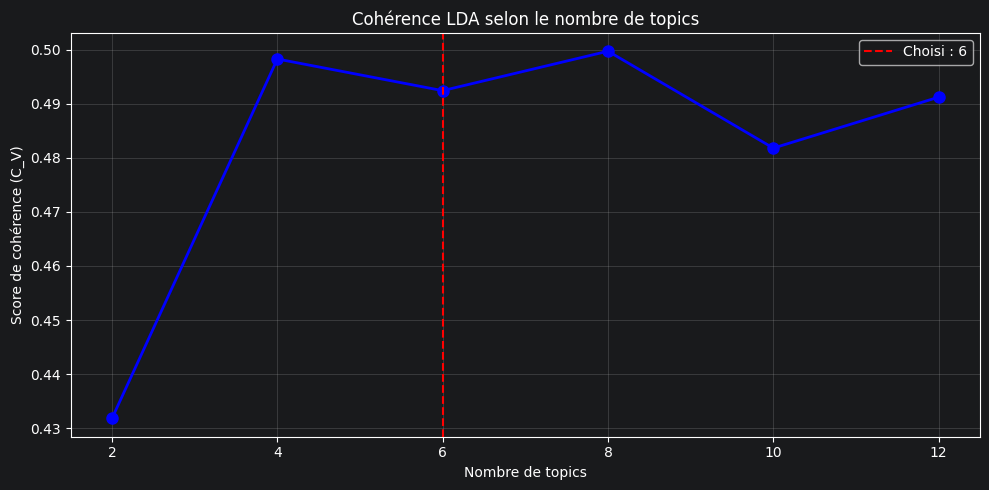

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(n_range, coherence_values, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=NUM_TOPICS, color='r', linestyle='--', label=f'Choisi : {NUM_TOPICS}')
plt.xlabel('Nombre de topics')
plt.ylabel('Score de cohérence (C_V)')
plt.title('Cohérence LDA selon le nombre de topics')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.6 Visualisation pyLDAvis

In [16]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus_bow, dictionary, sort_topics=False)
pyLDAvis.save_html(vis, str(MODELS_DIR / 'lda_visualization.html'))
print(f"{MODELS_DIR / 'lda_visualization.html'}")
pyLDAvis.display(vis)

/Users/amaitre/prive/4_ECOLE/S8/NLP/projet2/models/lda_visualization.html


## 3.7 Attribution des topics aux reviews

In [17]:
def get_dominant_topic(bow):
    probs = lda_model.get_document_topics(bow)
    if not probs:
        return 0, 0.0
    top = max(probs, key=lambda x: x[1])
    return top[0], float(top[1])

In [18]:
assignments = [get_dominant_topic(bow) for bow in corpus_bow]
df['topic_id'] = [a[0] for a in assignments]
df['topic_prob'] = [a[1] for a in assignments]
df['topic_label'] = df['topic_id'].map(TOPIC_LABELS)

In [19]:
print("Distribution des topics :")
print(df['topic_label'].value_counts())

Distribution des topics :
topic_label
Tarifs & Contrats      9067
Sinistres Auto         8396
Assurance Santé        2695
Problèmes & Litiges    2340
Satisfaction Client     875
Prise en Charge         727
Name: count, dtype: int64


In [20]:
print(f"total : {len(df)}")

total : 24100


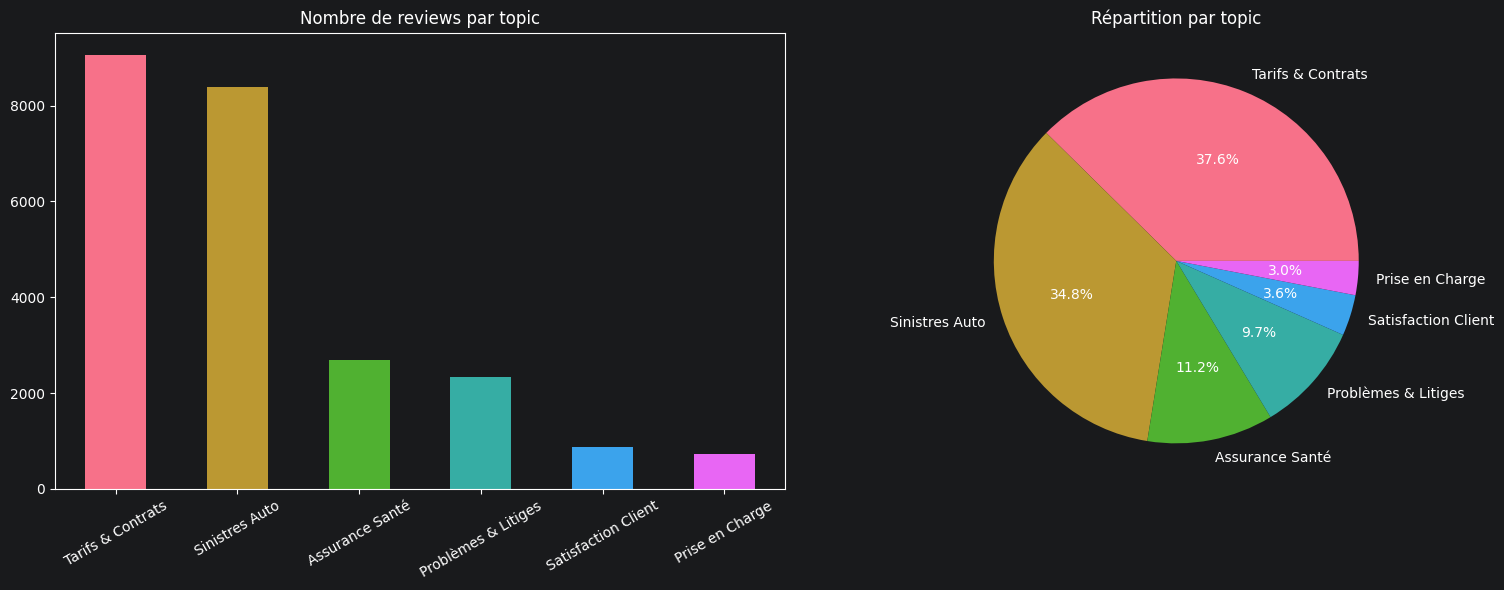

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette('husl', NUM_TOPICS)

topic_counts = df['topic_label'].value_counts()
topic_counts.plot(kind='bar', ax=axes[0], color=palette)
axes[0].set_title('Nombre de reviews par topic')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(topic_counts.values, labels=topic_counts.index, autopct='%1.1f%%', colors=palette)
axes[1].set_title('Répartition par topic')
plt.tight_layout()
plt.show()

In [22]:
print("Exemples de reviews par topic")
for tid, label in TOPIC_LABELS.items():
    reviews = df[df['topic_id'] == tid][TEXT_COL].dropna()
    print('=' * 55)
    print(f"Topic {tid}: {label}  ({len(reviews)} reviews)")
    print('=' * 55)
    for i, r in enumerate(reviews.head(2), 1):
        print(f"  [{i}] {str(r)[:200]}...")

Exemples de reviews par topic
Topic 0: Sinistres Auto  (8396 reviews)
  [1] La personne au téléphone était Clair et sympathique elle m'a bien tout expliqué je recommanderai votre assurance sans hésitation merci a la personne que j'ai contacté ...
  [2] Satisfait.

Réactivité, simplicité. Prix attractif d’un point de vue concurrence. A voir la réactivité des conseillers si besoin. Pour l’instant très satisfait.


...
Topic 1: Problèmes & Litiges  (2340 reviews)
  [1] ATTENTION ! ATTENTION ! au 1er sinistre vous êtes résiliés à l'échéance de votre contrat c est ce qui vient de m'arriver  suite à un sinistre de 1500 EUR    après avoir été client pendant 10 ans sans ...
  [2] L'année de ma souscription j'ai obtenu un bon tarif étant bonussé de 50 % depuis 2 ans. 
Ma grande surprise l'année suivante a été de voir ma prime augmentée de plus de 8% Alors que je n'avais eu aucu...
Topic 2: Tarifs & Contrats  (9067 reviews)
  [1] J'ai malheureusement eu à faire appel à plusieurs reprises à PACIF

## 3.8 Analyse croisée topics × étoiles

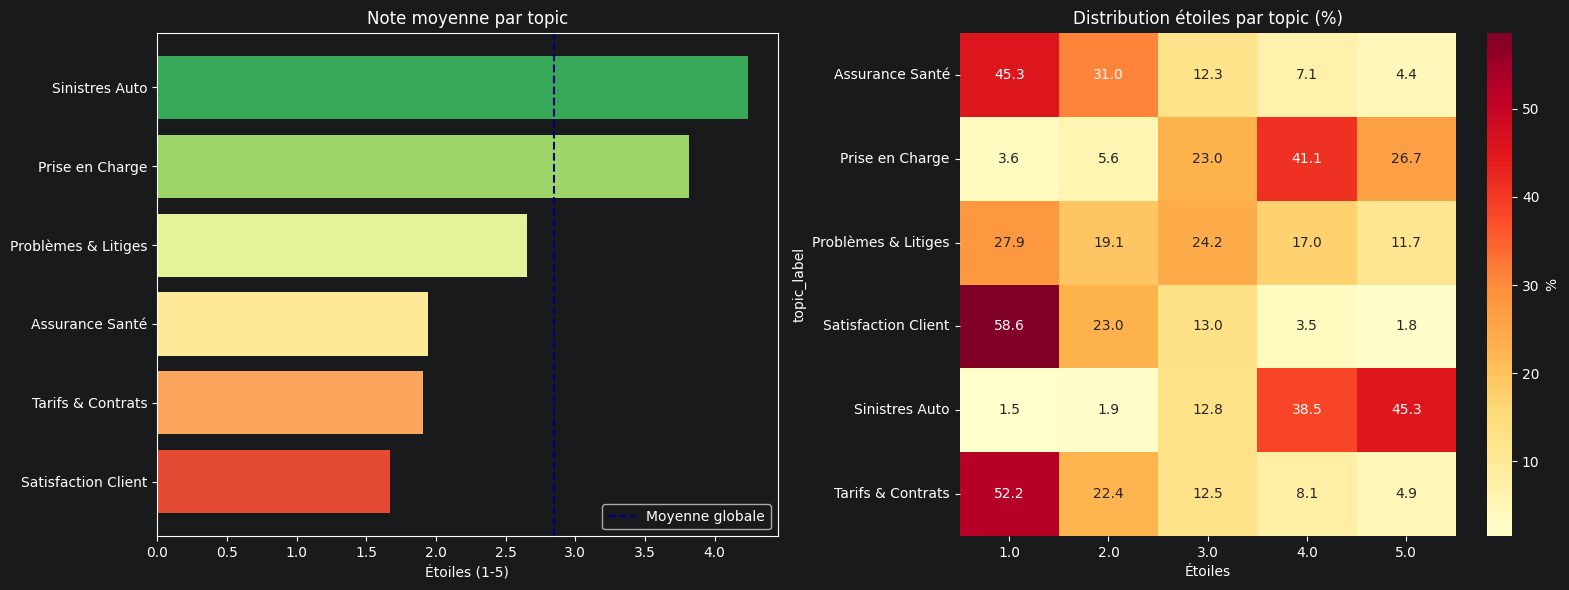

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avg_stars = df.groupby('topic_label')[RATING_COL].mean().sort_values()
colors = sns.color_palette('RdYlGn', len(avg_stars))
axes[0].barh(avg_stars.index, avg_stars.values, color=colors)
axes[0].axvline(df[RATING_COL].mean(), color='navy', linestyle='--', label='Moyenne globale')
axes[0].set_title('Note moyenne par topic')
axes[0].set_xlabel('Étoiles (1-5)')
axes[0].legend()

pivot = df.groupby(['topic_label', RATING_COL]).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': '%'})
axes[1].set_title('Distribution étoiles par topic (%)')
axes[1].set_xlabel('Étoiles')
plt.tight_layout()
plt.show()


## 3.9 Sauvegarde

In [24]:
lda_model.save(str(LDA_MODELS_DIR))
dictionary.save(str(DICTIONARIES_DIR))

In [25]:
df.to_csv(str(DATA_PROCESSED / 'reviews_topics.csv'), index=False)

## 3.10 Analyse de la distribution des probabilités de topic

On examine ici la distribution des probabilités d'appartenance au topic dominant pour chaque document.
Un score élevé indique que le document est fortement associé à un seul topic (thème clair),
tandis qu'un score faible indique un document ambigu appartenant à plusieurs topics à la fois.

On analyse également les documents dits "mixtes" — ceux dont la probabilité du topic dominant
est inférieure à 0.4 — pour comprendre s'ils forment des thèmes de transition ou simplement
des avis généralistes.

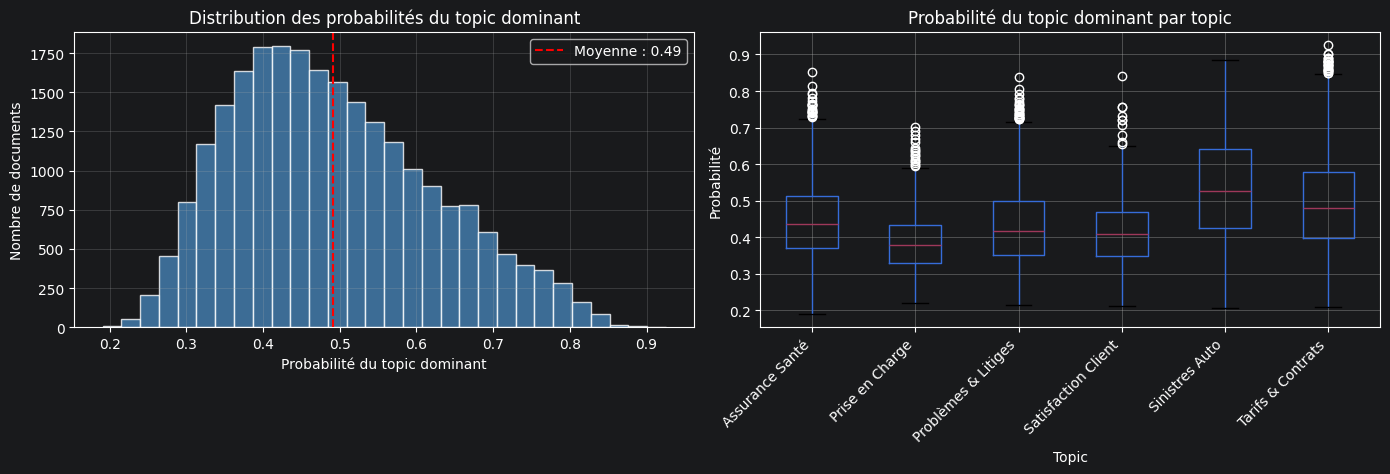

Documents ambigus (topic_prob < 0.4) : 6725 (27.9%)
Documents clairement assignés (topic_prob >= 0.4) : 17375 (72.1%)
Stats sur topic_prob :
count    24100.0000
mean         0.4913
std          0.1312
min          0.1906
25%          0.3903
50%          0.4737
75%          0.5793
max          0.9253
Name: topic_prob, dtype: float64


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global de topic_prob
axes[0].hist(df['topic_prob'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=df['topic_prob'].mean(), color='red', linestyle='--',
                label=f"Moyenne : {df['topic_prob'].mean():.2f}")
axes[0].set_title('Distribution des probabilités du topic dominant')
axes[0].set_xlabel('Probabilité du topic dominant')
axes[0].set_ylabel('Nombre de documents')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot par topic
df.boxplot(column='topic_prob', by='topic_label', ax=axes[1])
axes[1].set_title('Probabilité du topic dominant par topic')
axes[1].set_xlabel('Topic')
axes[1].set_ylabel('Probabilité')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Documents "mixtes" (faible certitude d'appartenance à un topic)
threshold = 0.4
mixed_docs = df[df['topic_prob'] < threshold]
print(f"Documents ambigus (topic_prob < {threshold}) : {len(mixed_docs)} ({len(mixed_docs) / len(df) * 100:.1f}%)")
print(
    f"Documents clairement assignés (topic_prob >= {threshold}) : {len(df) - len(mixed_docs)} ({(len(df) - len(mixed_docs)) / len(df) * 100:.1f}%)")

print(f"Stats sur topic_prob :")
print(df['topic_prob'].describe().round(4))